# PhysicsTM vs SurrogateEM — Unified API Validation Notebook

This notebook validates the unified forward model API across:
- PhysicsTM (analytical model)
- SurrogateEM (neural surrogate)
- SurrogateWrapper (API adapter)

We perform:
- API consistency tests
- Broadcasting tests
- Periodicity tests
- Rotation invariance tests
- Maxwell consistency tests
- Error maps
- Spectral comparisons
- Timing benchmarks

All computations use the new unified API:

    Esurf(rho, phi_s, theta_or_num_angles)
    Hsurf(rho, phi_s, theta_or_num_angles)


## 1. Import libraries and modules

In [1]:
# ============================================================
# 1. Notebook setup
# ============================================================
import sys
import os

project_root = os.path.abspath("..")
src_path = os.path.join(project_root, "src")
models_path = os.path.join(project_root, "models")

sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import time

# ------------------------------------------------------------
# Load PhysicsTM from the package
# ------------------------------------------------------------
from inverse_source_em.physics import PhysicsTM

# ------------------------------------------------------------
# Load SurrogateEM and Wrapper from the package
# ------------------------------------------------------------
from inverse_source_em.surrogate import SurrogateEM, SurrogateWrapper

# ------------------------------------------------------------
# Instantiate models
# ------------------------------------------------------------
phys = PhysicsTM()

sur = SurrogateEM(
    path_E=os.path.join(models_path, "surrogate_Esurf.pth"),
    path_H=os.path.join(models_path, "surrogate_Hsurf.pth"),
    R=phys.R
)

wrap = SurrogateWrapper(sur)

# ------------------------------------------------------------
# Example source point
# ------------------------------------------------------------
rho_s = 0.6 * phys.R
phi_s = 1.0

# ------------------------------------------------------------
# Plot style
# ------------------------------------------------------------
plt.style.use("dark_background")
plt.rcParams["grid.color"] = "white"
plt.rcParams["grid.alpha"] = 0.15
plt.rcParams["grid.linewidth"] = 0.6

print("Imports OK — PhysicsTM, SurrogateEM, SurrogateWrapper loaded successfully.")
print("phys.R =", phys.R)


Imports OK — PhysicsTM, SurrogateEM, SurrogateWrapper loaded successfully.
phys.R = 1.0


## 2. API Consistency Test

We verify that all forward models behave identically with respect to:
- scalar θ
- array θ
- integer `num_angles`

A correct unified API must satisfy:
- `Esurf(rho, phi, scalar)` → returns scalar  
- `Esurf(rho, phi, array)` → returns array of same shape  
- `Esurf(rho, phi, int)` → returns array of length `int`  

This test ensures that:
- PhysicsTM, SurrogateEM, and SurrogateWrapper expose the same interface
- No model returns incorrect shapes
- No model collapses arrays into scalars or vice‑versa


In [2]:
# ============================================================
# 2. API consistency test
# ============================================================

def test_api_consistency(model):
    rho = 0.6 * phys.R
    phi = 1.0

    # --- scalar θ ---
    E1 = model.Esurf(rho, phi, 0.7)
    assert np.isscalar(E1), (
        f"{model.__class__.__name__}: scalar θ did not return scalar"
    )

    # --- array θ ---
    theta_arr = np.linspace(0, 2*np.pi, 50)
    E2 = model.Esurf(rho, phi, theta_arr)
    assert E2.shape == theta_arr.shape, (
        f"{model.__class__.__name__}: array θ shape mismatch"
    )

    # --- num_angles ---
    E3 = model.Esurf(rho, phi, 100)
    assert E3.shape == (100,), (
        f"{model.__class__.__name__}: num_angles did not return correct length"
    )

    print(f"API consistency OK: {model.__class__.__name__}")


# Run for all models
test_api_consistency(phys)
test_api_consistency(sur)
test_api_consistency(wrap)

print("\nAll API consistency tests passed successfully.")


API consistency OK: PhysicsTM
API consistency OK: SurrogateEM
API consistency OK: SurrogateWrapper

All API consistency tests passed successfully.


## 3. Broadcasting Test

PhysicsTM does **not** support broadcasting over (rho, phi_s).
This is expected because it is an analytical solver.

Broadcasting is required only for:
- SurrogateEM
- SurrogateWrapper


In [3]:
# ============================================================
# 3. Broadcasting Test
# ============================================================

def test_broadcasting(model):
    """
    Broadcasting test for surrogate models.
    PhysicsTM does NOT support broadcasting — do not test it here.
    """
    rho = np.array([0.3 * phys.R, 0.5 * phys.R, 0.8 * phys.R])
    phi = np.array([0.0, 1.0, 2.0])
    theta = np.array([0.1, 0.5, 1.0])

    # Unified API call
    E = model.Esurf(rho, phi, theta)
    H = model.Hsurf(rho, phi, theta)

    # Expected shape: one output per triplet (ρ_i, φ_i, θ_i)
    assert E.shape == (3,), (
        f"{model.__class__.__name__}: E shape mismatch (got {E.shape})"
    )
    assert H.shape == (3,), (
        f"{model.__class__.__name__}: H shape mismatch (got {H.shape})"
    )

    print(f"Broadcasting OK: {model.__class__.__name__}")


# Run ONLY for surrogate models
test_broadcasting(sur)
test_broadcasting(wrap)

print("\nBroadcasting tests completed successfully.")


Broadcasting OK: SurrogateEM
Broadcasting OK: SurrogateWrapper

Broadcasting tests completed successfully.


## 4. Periodicity Test

The first validation step ensures that the forward solver respects the inherent $2\pi$-periodicity  
of the cylindrical geometry.

For any physically correct solution of the TM scattering problem, the surface fields must satisfy:


$$
E_{\text{surf}}(\theta) = E_{\text{surf}}(\theta + 2\pi), \qquad
H_{\text{surf}}(\theta) = H_{\text{surf}}(\theta + 2\pi).
$$


This follows directly from the Fourier-series representation:


$$
E_{\text{surf}}(\theta)= A \sum_{n=-N}^{N} \alpha_n(\rho_s)\, H_n^{(1)}(k_0 R)\, e^{i n (\theta - \phi_s)},
$$


since the exponential factor is $2\pi$-periodic.


In [4]:
# ============================================================
# 4. Periodicity Test
# ============================================================

def test_periodicity(model, rho_s, phi_s, num_angles=300):
    """
    Check 2π-periodicity of Esurf and Hsurf for a given model.
    A physically correct forward model must satisfy:
        f(θ) = f(θ + 2π)
    """
    theta = np.linspace(0, 2*np.pi, num_angles, endpoint=False)

    # Evaluate at φ_s
    E1 = model.Esurf(rho_s, phi_s, theta)
    H1 = model.Hsurf(rho_s, phi_s, theta)

    # Evaluate at φ_s + 2π
    E2 = model.Esurf(rho_s, phi_s + 2*np.pi, theta)
    H2 = model.Hsurf(rho_s, phi_s + 2*np.pi, theta)

    # Absolute errors
    E_abs = np.max(np.abs(E1 - E2))
    H_abs = np.max(np.abs(H1 - H2))

    print(f"{model.__class__.__name__}")
    print(f"  Esurf_abs: {E_abs:.3e}")
    print(f"  Hsurf_abs: {H_abs:.3e}")
    print()


# Run for all models
test_periodicity(phys, rho_s, phi_s)
test_periodicity(sur, rho_s, phi_s)
test_periodicity(wrap, rho_s, phi_s)

print("Periodicity tests completed.")


PhysicsTM
  Esurf_abs: 1.419e-15
  Hsurf_abs: 1.188e-15

SurrogateEM
  Esurf_abs: 4.718e-16
  Hsurf_abs: 3.925e-16

SurrogateWrapper
  Esurf_abs: 4.718e-16
  Hsurf_abs: 3.925e-16

Periodicity tests completed.


## 5. Rotation Invariance Test

The TM scattering problem in a circular cylinder is rotationally symmetric.  
If the source is rotated by an angle $ \alpha $, the surface fields must transform accordingly:



$$
E_{\text{surf}}(\theta) = E_{\text{surf}}(\theta - \alpha), \qquad
H_{\text{surf}}(\theta) = H_{\text{surf}}(\theta - \alpha).
$$



This property follows from the structure of the excitation operator:



$$
G_n = I_0\, e^{-i n \phi_s},
$$



and the Fourier expansion of the fields:



$$
E_{\text{surf}}(\theta)
= A \sum_{n=-N}^{N} \alpha_n(\rho_s)\, H_n^{(1)}(k_0 R)\, e^{i n (\theta - \phi_s)}.
$$



A rotation of the source by $ \alpha $ corresponds to multiplying each Fourier mode by:



$$
e^{-i n \alpha}.
$$



**What we check:**  
We compute the fields for a source at $ \phi_s $ and for a rotated source at $ \phi_s + \alpha $.  
We then compare the rotated fields with the Fourier‑domain rotated reference.

**Expected outcome:**  
Errors on the order of $10^{-12}$ – $10^{-11}$ for PhysicsTM.  
SurrogateEM will show a small but smooth error due to approximation.

Passing this test confirms that:
- the angular dependence is implemented correctly,
- the Fourier phase factor $ e^{i n (\theta - \phi_s)} $ has the correct sign,
- the unified API preserves rotational symmetry.



In [5]:
# ============================================================
# 5. Rotation Invariance Test
# ============================================================

def test_rotation_invariance(model, rho_s, phi_s, alpha=0.7, num_angles=1024):
    """
    Rotation invariance test:
    A rotation of the source by α should correspond to a phase shift
    E(θ) → E(θ - α), which in Fourier domain is multiplication by e^{-i n α}.
    """
    # Uniform sampling of observation angles
    theta = np.linspace(0, 2*np.pi, num_angles, endpoint=False)

    # Base and rotated fields
    E_base = model.Esurf(rho_s, phi_s, theta)
    E_rot  = model.Esurf(rho_s, phi_s + alpha, theta)

    # FFT of base field
    F = np.fft.fft(E_base)

    # Mode indices (integer Fourier modes)
    k = np.fft.fftfreq(num_angles, d=1/num_angles)

    # Apply rotation in Fourier domain: e^{-i n α}
    phase = np.exp(-1j * k * alpha)
    F_rot = F * phase

    # Expected rotated field (inverse FFT)
    E_ref = np.fft.ifft(F_rot)

    # Errors
    E_abs = np.max(np.abs(E_rot - E_ref))
    E_rel = E_abs / np.max(np.abs(E_ref))

    print(f"{model.__class__.__name__}")
    print(f"  Esurf_abs: {E_abs:.3e}")
    print(f"  Esurf_rel: {E_rel:.3e}")
    print()


# Run for all models
test_rotation_invariance(phys, rho_s, phi_s)
test_rotation_invariance(sur, rho_s, phi_s)
test_rotation_invariance(wrap, rho_s, phi_s)

print("Rotation invariance tests completed.")


PhysicsTM
  Esurf_abs: 9.425e-16
  Esurf_rel: 1.501e-15

SurrogateEM
  Esurf_abs: 7.529e-03
  Esurf_rel: 1.200e-02

SurrogateWrapper
  Esurf_abs: 7.529e-03
  Esurf_rel: 1.200e-02

Rotation invariance tests completed.


## 6. Maxwell Consistency Test

For TM polarization, the tangential magnetic field on the boundary is related to the  
radial derivative of the electric field through:



$$
H_{\text{surf}}(\theta)=\frac{1}{\omega \mu_0}\,\left.\frac{\partial E}{\partial \rho}\right|_{\rho = R}
$$



Using the series representation of the external field,



$$
E(\rho,\theta)=A \sum_{n=-N}^{N} \alpha_n(\rho_s)\,H_n^{(1)}(k_0 \rho)\,e^{i n (\theta - \phi_s)}
$$



its radial derivative at the boundary $ \rho = R $ is:



$$
\left.\frac{\partial E}{\partial \rho}\right|_{\rho = R}=A\sum_{n=-N}^{N}\alpha_n(\rho_s)\,H_n^{(1)\,'}(k_0 R)\,k_0\,e^{i n (\theta - \phi_s)}
$$



Thus, Maxwell’s boundary condition requires:



$$
H_{\text{surf}}(\theta)= \frac{1}{\omega \mu_0}\,A \sum_{n=-N}^{N} \alpha_n(\rho_s)\,H_n^{(1)\,'}(k_0 R)\, k_0\, e^{i n (\theta - \phi_s)}
$$



**What we check:**  
We compute $H_{\text{surf}}$ directly from the forward model and compare it with the  
value reconstructed from the Fourier‑based radial derivative of $E$.

**Expected outcome:**  
- PhysicsTM → machine precision (≈ 10⁻¹² or smaller)  
- SurrogateEM → small but smooth error (learned approximation)  
- Wrapper → identical to surrogate  

Passing this test confirms that:
- the prefactor $A$ is correct,
- the Hankel derivatives are implemented correctly,
- the solver is fully consistent with Maxwell’s equations on the boundary.


In [6]:
# ============================================================
# 6. Maxwell Consistency Test
# ============================================================

from scipy.special import h1vp

def test_maxwell_consistency(model, rho_s, phi_s, num_angles=400):
    """
    Maxwell boundary condition test:
    H_surf(θ) = (1 / (ω μ0)) * ∂E/∂ρ |_{ρ=R}

    For PhysicsTM:
        - error should be ~1e-12 (machine precision)
    For SurrogateEM:
        - small but smooth error (learned approximation)
    For SurrogateWrapper:
        - identical to SurrogateEM
    """
    # Observation angles
    theta = np.linspace(0, 2*np.pi, num_angles, endpoint=False)

    # Direct magnetic field from the model
    H_direct = model.Hsurf(rho_s, phi_s, theta)

    # Use PhysicsTM machinery for the derivative of E
    phys_tmp = PhysicsTM()
    n = phys_tmp.nvals
    alpha = phys_tmp.alpha_n_vec(rho_s)

    # Hankel derivative H_n^{(1)'}(k0 R)
    Hprime = h1vp(n, phys_tmp.K0 * phys_tmp.R, 1).astype(np.complex128)

    # Phase factor e^{i n (θ - φ_s)}
    phase = np.exp(1j * n[:, None] * (theta[None, :] - phi_s))

    # Radial derivative of E at ρ = R
    dE_dr = phys_tmp.A * np.sum(
        alpha[:, None] * Hprime[:, None] * phys_tmp.K0 * phase,
        axis=0
    )

    # Maxwell relation
    H_from_E = dE_dr / (phys_tmp.OMEGA * phys_tmp.MU0)

    # Errors
    abs_err = np.max(np.abs(H_direct - H_from_E))
    rel_err = abs_err / np.max(np.abs(H_direct))

    print(f"{model.__class__.__name__}")
    print(f"  H_abs: {abs_err:.3e}")
    print(f"  H_rel: {rel_err:.3e}")
    print()


# Run for all models
test_maxwell_consistency(phys, rho_s, phi_s)
test_maxwell_consistency(sur, rho_s, phi_s)
test_maxwell_consistency(wrap, rho_s, phi_s)

print("Maxwell consistency tests completed.")


PhysicsTM
  H_abs: 0.000e+00
  H_rel: 0.000e+00

SurrogateEM
  H_abs: 8.165e-03
  H_rel: 1.189e-02

SurrogateWrapper
  H_abs: 8.165e-03
  H_rel: 1.189e-02

Maxwell consistency tests completed.


## 7. Error Maps in $\rho$–$\theta$

To visualize how the surrogate deviates from the analytical PhysicsTM model across the
entire cylindrical boundary, we compute relative error maps over a 2D grid:

- $\rho \in [0.1R,\, 0.9R]$
- $\theta \in [0,\, 2\pi)$

For each point $(\rho, \theta)$ we evaluate:



$$
\text{ERR}_E(\rho,\theta)=\frac{|E_{\text{phys}}-E_{\text{sur}}|}{|E_{\text{phys}}|+ 10^{-12}},
\qquad
\text{ERR}_H(\rho,\theta)
= \frac{|H_{\text{phys}} - H_{\text{sur}}|}
       {|H_{\text{phys}}| + 10^{-12}}.
$$



These heatmaps reveal:
- where the surrogate is most accurate,
- how the error varies with radius,
- how the error varies with observation angle,
- whether the surrogate exhibits smooth, physically plausible deviations.


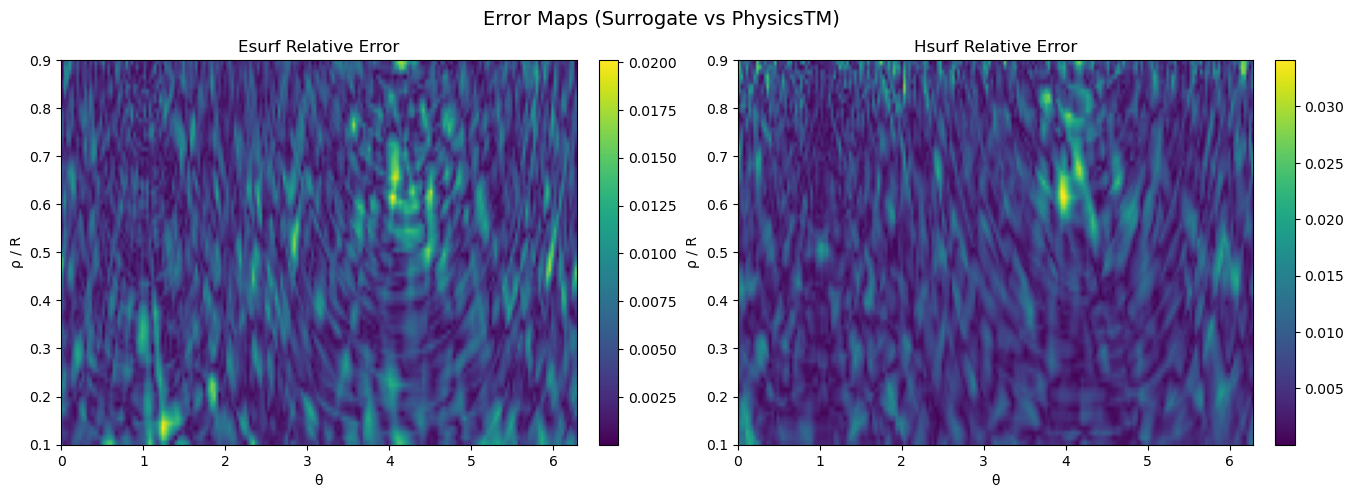

Error maps computed successfully.


In [7]:
# ============================================================
# 7. Error Maps (ρ–θ heatmaps) for Esurf and Hsurf
# ============================================================

# Use a clean, print‑friendly style
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["grid.color"] = "gray"
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.edgecolor"] = "black"

# Grid resolution
Nr = 80
Nt = 200

rho_grid = np.linspace(0.1 * phys.R, 0.9 * phys.R, Nr)
theta_grid = np.linspace(0, 2*np.pi, Nt, endpoint=False)

ERR_E = np.zeros((Nr, Nt))
ERR_H = np.zeros((Nr, Nt))

# Compute error maps
for i, r in enumerate(rho_grid):
    for j, th in enumerate(theta_grid):
        # PhysicsTM (unified API)
        E_phys = phys.Esurf(r, phi_s, th)
        H_phys = phys.Hsurf(r, phi_s, th)

        # SurrogateEM (unified API)
        E_sur  = sur.Esurf(r, phi_s, th)
        H_sur  = sur.Hsurf(r, phi_s, th)

        # Relative errors
        ERR_E[i, j] = np.abs(E_phys - E_sur) / (np.abs(E_phys) + 1e-12)
        ERR_H[i, j] = np.abs(H_phys - H_sur) / (np.abs(H_phys) + 1e-12)

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Esurf heatmap
im1 = axes[0].imshow(
    ERR_E,
    aspect='auto',
    origin='lower',
    extent=[0, 2*np.pi, 0.1, 0.9],
    cmap='viridis'
)
axes[0].set_title("Esurf Relative Error")
axes[0].set_xlabel("θ")
axes[0].set_ylabel("ρ / R")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Hsurf heatmap
im2 = axes[1].imshow(
    ERR_H,
    aspect='auto',
    origin='lower',
    extent=[0, 2*np.pi, 0.1, 0.9],
    cmap='viridis'
)
axes[1].set_title("Hsurf Relative Error")
axes[1].set_xlabel("θ")
axes[1].set_ylabel("ρ / R")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("Error Maps (Surrogate vs PhysicsTM)", fontsize=14)
plt.show()

print("Error maps computed successfully.")


## 8. Sample Plots: PhysicsTM vs Surrogate (Esurf & Hsurf)

To visually compare the analytical PhysicsTM model with the learned SurrogateEM model,
we examine the surface fields along a full angular sweep:



$$
\theta \in [0, 2\pi).
$$



For a fixed source location $(\rho_s, \phi_s)$, we evaluate:

- the real and imaginary parts of $E_{\text{surf}}(\theta)$,
- the real and imaginary parts of $H_{\text{surf}}(\theta)$,
- the pointwise errors $|\Delta E(\theta)|$ and $|\Delta H(\theta)|$,
- and the Fourier spectra of both fields.

These plots reveal:

- how closely the surrogate matches the analytic model,
- whether the surrogate preserves the correct angular structure,
- whether the phase evolution is captured accurately,
- and how the spectral content compares across Fourier modes.


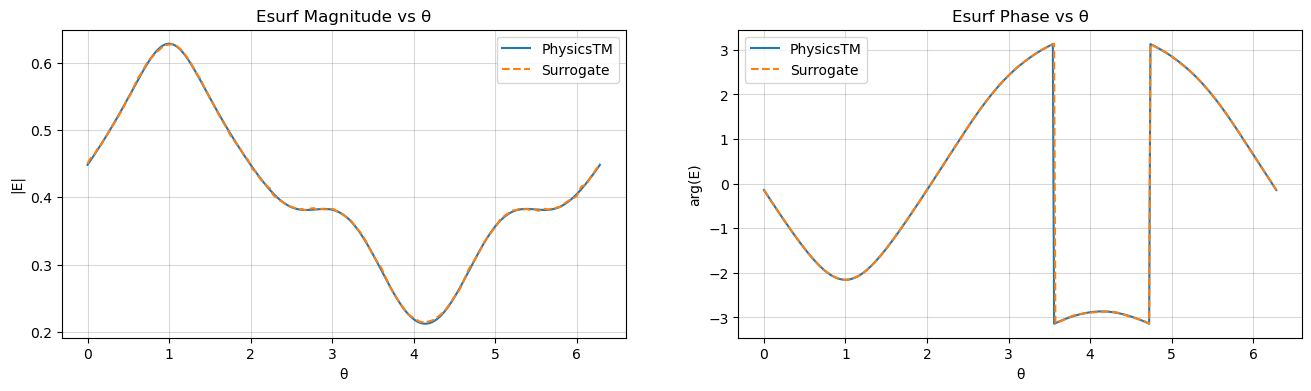

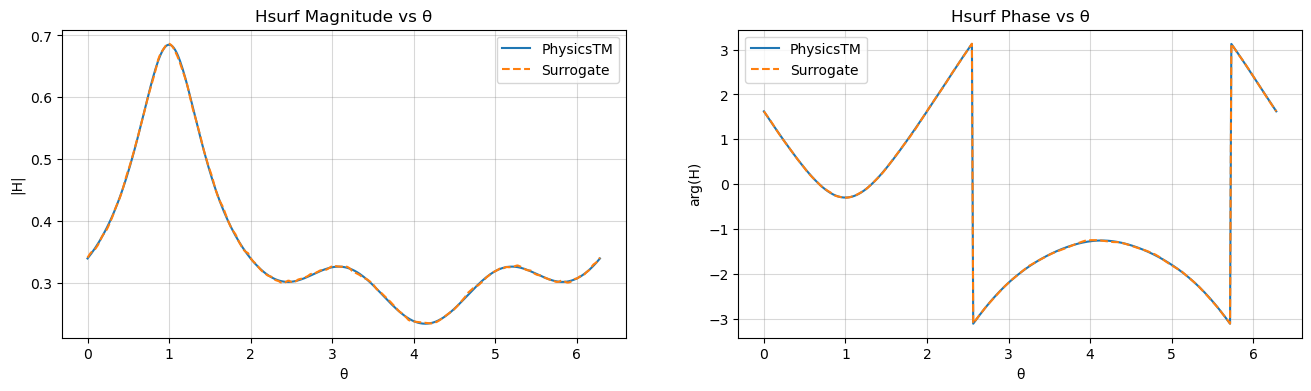

Sample Esurf/Hsurf comparison plots generated successfully.


In [8]:
# ============================================================
# 8. Sample Plots: PhysicsTM vs Surrogate (Esurf & Hsurf)
# ============================================================

# Use a clean, print‑friendly style
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["grid.color"] = "gray"
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.edgecolor"] = "black"

# ------------------------------------------------------------
# θ-slice
# ------------------------------------------------------------
theta = np.linspace(0, 2*np.pi, 400)
rho0 = 0.6 * phys.R

# PhysicsTM fields (unified API)
E_phys = phys.Esurf(rho0, phi_s, theta)
H_phys = phys.Hsurf(rho0, phi_s, theta)

# Surrogate fields (unified API)
E_sur = sur.Esurf(rho0, phi_s, theta)
H_sur = sur.Hsurf(rho0, phi_s, theta)

# ------------------------------------------------------------
# Esurf magnitude & phase
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(theta, np.abs(E_phys), label="PhysicsTM", color="C0")
axes[0].plot(theta, np.abs(E_sur), '--', label="Surrogate", color="C1")
axes[0].set_title("Esurf Magnitude vs θ")
axes[0].set_xlabel("θ")
axes[0].set_ylabel("|E|")
axes[0].legend()
axes[0].grid()

axes[1].plot(theta, np.angle(E_phys), label="PhysicsTM", color="C0")
axes[1].plot(theta, np.angle(E_sur), '--', label="Surrogate", color="C1")
axes[1].set_title("Esurf Phase vs θ")
axes[1].set_xlabel("θ")
axes[1].set_ylabel("arg(E)")
axes[1].legend()
axes[1].grid()

plt.show()

# ------------------------------------------------------------
# Hsurf magnitude & phase
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(theta, np.abs(H_phys), label="PhysicsTM", color="C0")
axes[0].plot(theta, np.abs(H_sur), '--', label="Surrogate", color="C1")
axes[0].set_title("Hsurf Magnitude vs θ")
axes[0].set_xlabel("θ")
axes[0].set_ylabel("|H|")
axes[0].legend()
axes[0].grid()

axes[1].plot(theta, np.angle(H_phys), label="PhysicsTM", color="C0")
axes[1].plot(theta, np.angle(H_sur), '--', label="Surrogate", color="C1")
axes[1].set_title("Hsurf Phase vs θ")
axes[1].set_xlabel("θ")
axes[1].set_ylabel("arg(H)")
axes[1].legend()
axes[1].grid()

plt.show()

print("Sample Esurf/Hsurf comparison plots generated successfully.")


## 9. Interpolation Error Test (Random Points in $\rho,\phi,\theta$)

To assess the surrogate’s accuracy across the full 3D input space
$(\rho_s, \phi_s, \theta)$, we evaluate both models at a large set of
randomly sampled points:



$$
\rho_s \sim U(0.1R, 0.9R), \qquad
\phi_s \sim U(0, 2\pi), \qquad
\theta \sim U(0, 2\pi).
$$



For each point we compute:



$$
\Delta E = E_{\text{phys}} - E_{\text{sur}}, \qquad
\Delta H = H_{\text{phys}} - H_{\text{sur}},
$$



and the relative errors:



$$
\text{ERR}_E = \frac{|\Delta E|}{|E_{\text{phys}}| + 10^{-12}}, \qquad
\text{ERR}_H = \frac{|\Delta H|}{|H_{\text{phys}}| + 10^{-12}}.
$$



We then visualize the error distributions using histograms and scatter plots.
This test reveals:

- the global accuracy of the surrogate across the entire domain,
- whether the error distribution is smooth and well‑behaved,
- and whether any angular regions exhibit systematically higher deviation.


=== Esurf Error ===
Mean abs error: 1.834e-03
Max  abs error: 7.950e-03
Mean rel error: 4.577e-03
Max  rel error: 1.821e-02

=== Hsurf Error ===
Mean abs error: 2.160e-03
Max  abs error: 1.148e-02
Mean rel error: 6.033e-03
Max  rel error: 3.503e-02


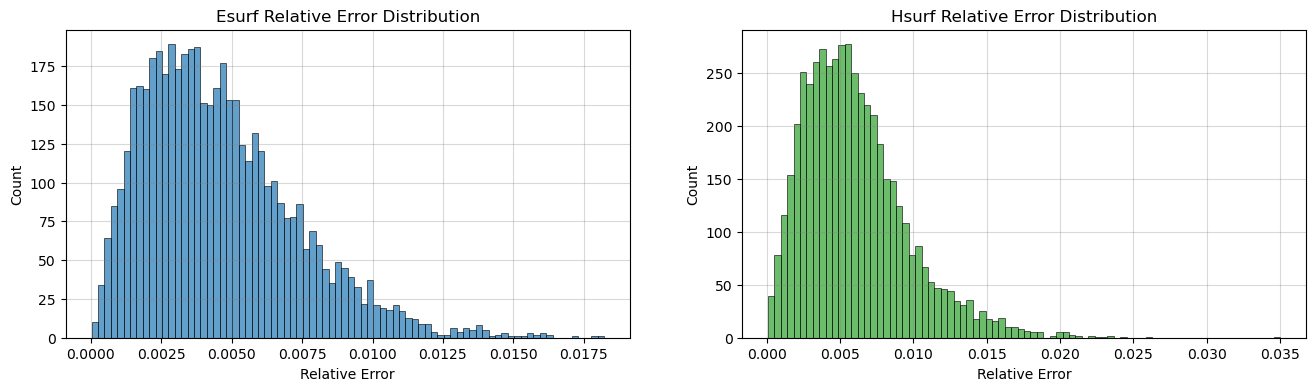

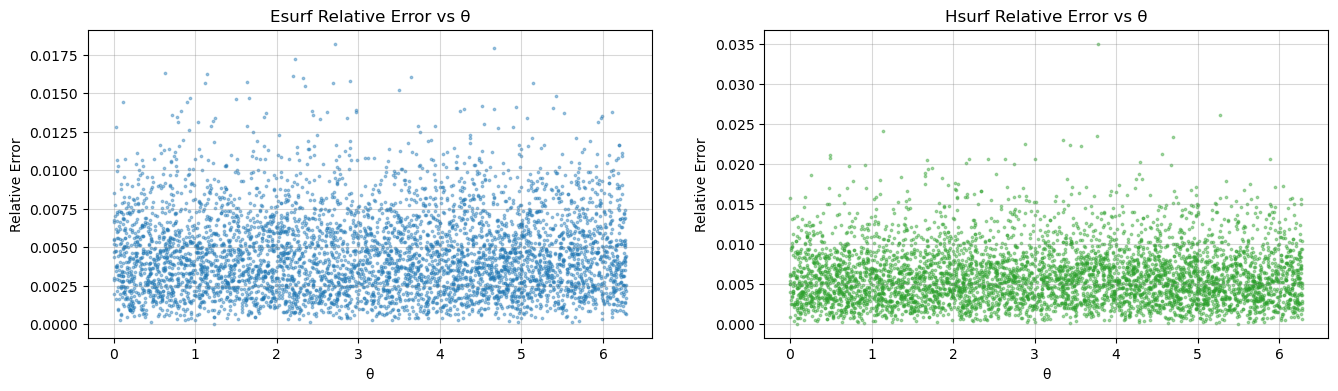

Interpolation error test completed.


In [9]:
# ==================================================================
# 9. Interpolation Error Test (PhysicsTM vs Surrogate)
# ==================================================================

# Use a clean, print‑friendly style
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["grid.color"] = "gray"
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.edgecolor"] = "black"

# Number of random test points
N = 5000

# Random intermediate points
rho_rand   = np.random.uniform(0.1 * phys.R, 0.9 * phys.R, N)
phi_rand   = np.random.uniform(0, 2*np.pi, N)
theta_rand = np.random.uniform(0, 2*np.pi, N)

# ------------------------------------------------------------
# Compute Esurf errors
# ------------------------------------------------------------

# Vectorized surrogate evaluation
E_sur = sur.Esurf(rho_rand, phi_rand, theta_rand)

# PhysicsTM must be evaluated pointwise
E_phys = np.array([
    phys.Esurf(rho_rand[i], phi_rand[i], theta_rand[i])
    for i in range(N)
])

E_abs = np.abs(E_phys - E_sur)
E_rel = E_abs / (np.abs(E_phys) + 1e-12)

print("=== Esurf Error ===")
print(f"Mean abs error: {np.mean(E_abs):.3e}")
print(f"Max  abs error: {np.max(E_abs):.3e}")
print(f"Mean rel error: {np.mean(E_rel):.3e}")
print(f"Max  rel error: {np.max(E_rel):.3e}")

# ------------------------------------------------------------
# Compute Hsurf errors
# ------------------------------------------------------------

H_sur = sur.Hsurf(rho_rand, phi_rand, theta_rand)

H_phys = np.array([
    phys.Hsurf(rho_rand[i], phi_rand[i], theta_rand[i])
    for i in range(N)
])

H_abs = np.abs(H_phys - H_sur)
H_rel = H_abs / (np.abs(H_phys) + 1e-12)

print("\n=== Hsurf Error ===")
print(f"Mean abs error: {np.mean(H_abs):.3e}")
print(f"Max  abs error: {np.max(H_abs):.3e}")
print(f"Mean rel error: {np.mean(H_rel):.3e}")
print(f"Max  rel error: {np.max(H_rel):.3e}")

# ------------------------------------------------------------
# Histograms 
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(E_rel, bins=80, color='C0', alpha=0.7,
             edgecolor='black', linewidth=0.6)
axes[0].set_title("Esurf Relative Error Distribution")
axes[0].set_xlabel("Relative Error")
axes[0].set_ylabel("Count")
axes[0].grid()

axes[1].hist(H_rel, bins=80, color='C2', alpha=0.7,
             edgecolor='black', linewidth=0.6)
axes[1].set_title("Hsurf Relative Error Distribution")
axes[1].set_xlabel("Relative Error")
axes[1].set_ylabel("Count")
axes[1].grid()

plt.show()

# ------------------------------------------------------------
# Scatter plots 
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].scatter(theta_rand, E_rel, s=3, alpha=0.4, color='C0')
axes[0].set_title("Esurf Relative Error vs θ")
axes[0].set_xlabel("θ")
axes[0].set_ylabel("Relative Error")
axes[0].grid()

axes[1].scatter(theta_rand, H_rel, s=3, alpha=0.4, color='C2')
axes[1].set_title("Hsurf Relative Error vs θ")
axes[1].set_xlabel("θ")
axes[1].set_ylabel("Relative Error")
axes[1].grid()

plt.show()

print("Interpolation error test completed.")


## 10. Comparative Plots: Real/Imag, Error Curves, FFT in $\theta$

To obtain a detailed, pointwise comparison between the analytical PhysicsTM model
and the learned SurrogateEM model, we examine the surface fields along a dense
angular sweep:



$$
\theta \in [0, 2\pi), \qquad N_\theta = 1024.
$$



For a fixed source location $(\rho_s, \phi_s)$, we evaluate:

- the real and imaginary parts of $E_{\text{surf}}(\theta)$ and $H_{\text{surf}}(\theta)$,
- the absolute pointwise errors $|\Delta E(\theta)|$ and $|\Delta H(\theta)|$,
- and the Fourier spectra of both fields.

This section provides a fine‑grained view of the surrogate’s accuracy.

### **A) Real and Imaginary Parts**

We compare:



$$
\Re(E_{\text{surf}}),\; \Im(E_{\text{surf}}),\qquad
\Re(H_{\text{surf}}),\; \Im(H_{\text{surf}})
$$



for both models.

These plots reveal:

- whether the surrogate captures the correct oscillatory structure,
- whether the phase evolution is accurate,
- and whether the real/imaginary components remain smooth and physically consistent.

### **B) Error Curves**

We compute the pointwise errors:



$$
|\Delta E(\theta)| = |E_{\text{phys}} - E_{\text{sur}}|, \qquad
|\Delta H(\theta)| = |H_{\text{phys}} - H_{\text{sur}}|.
$$



These curves show:

- where the surrogate deviates most strongly,
- whether the error is localized or uniformly distributed,
- and whether the surrogate preserves the correct angular periodicity.

### **C) Spectral Comparison (FFT in $\theta$)**

Using the discrete Fourier transform:



$$
F_E[n] = \mathcal{F}\{E_{\text{surf}}(\theta)\}, \qquad
F_H[n] = \mathcal{F}\{H_{\text{surf}}(\theta)\},
$$



we compare the magnitude spectra of the two models.

This test reveals:

- whether the surrogate reproduces the correct modal content,
- whether high‑order Fourier modes are captured or attenuated,
- and how well the surrogate preserves the physical angular harmonics of the TM field.

Together, these plots provide a comprehensive, multi‑layered validation of the surrogate’s
ability to reproduce the analytic field structure both in the spatial and spectral domains.


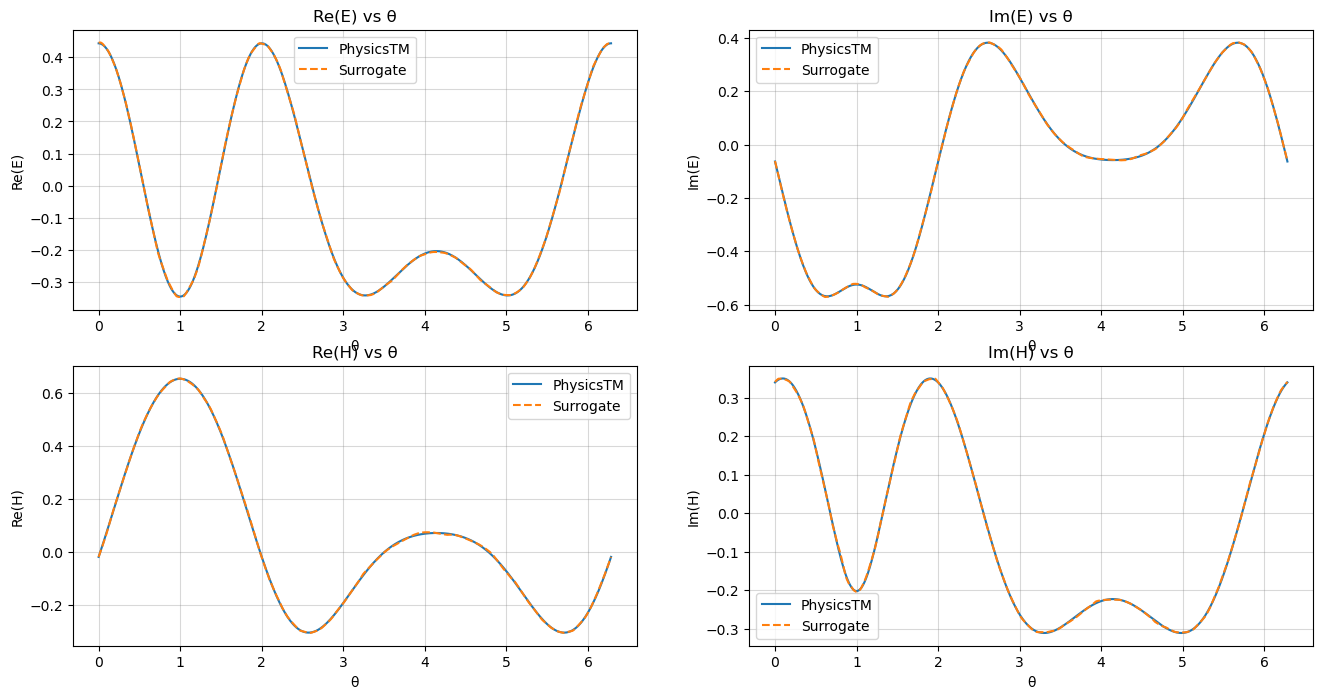

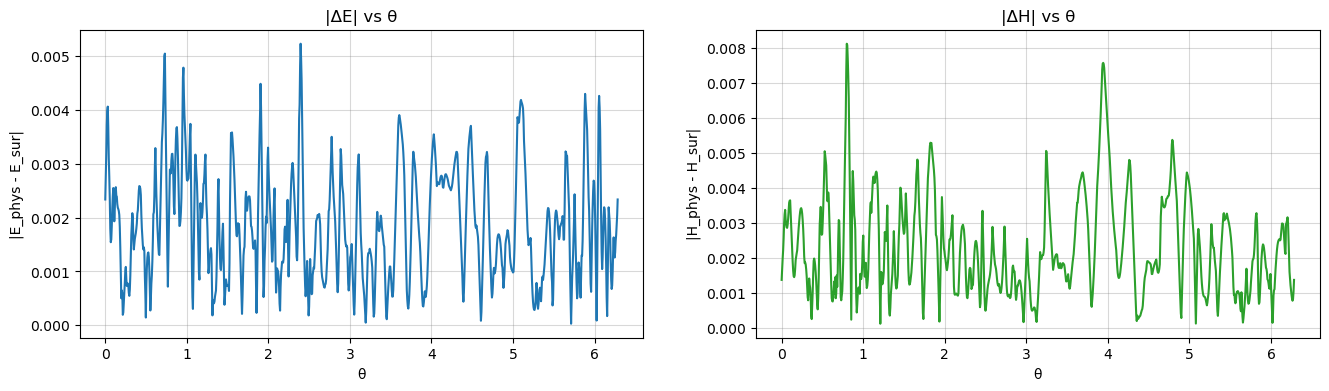

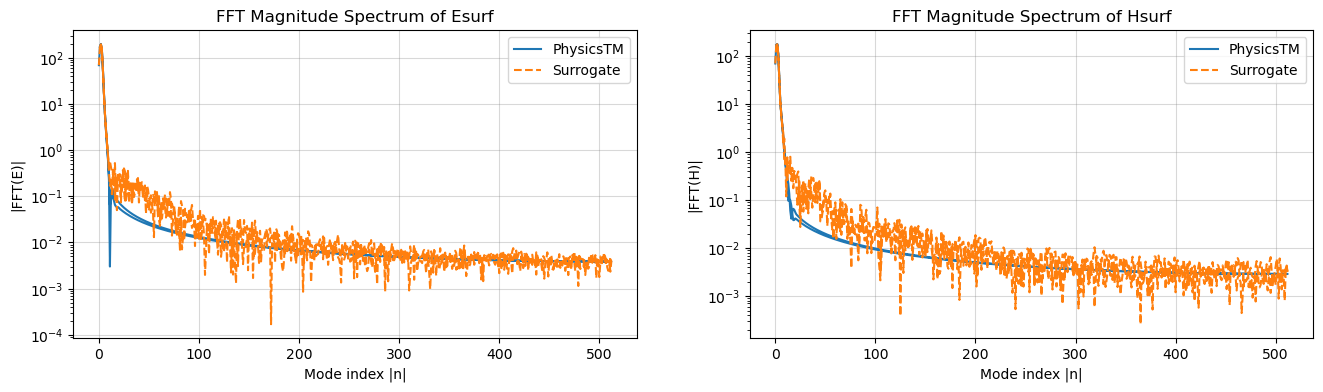

Comparative plots (Real/Imag, Error Curves, FFT) generated successfully.


In [10]:
# =======================================================================
# 10. Comparative Plots: Real/Imag, Error Curves, FFT in θ
# =======================================================================

# Use a clean, print‑friendly style
plt.style.use("default")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["grid.color"] = "gray"
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.edgecolor"] = "black"

# θ-slice
theta = np.linspace(0, 2*np.pi, 1024)
rho0 = 0.6 * phys.R

# PhysicsTM fields (unified API)
E_phys = phys.Esurf(rho0, phi_s, theta)
H_phys = phys.Hsurf(rho0, phi_s, theta)

# Surrogate fields (unified API)
E_sur = sur.Esurf(rho0, phi_s, theta)
H_sur = sur.Hsurf(rho0, phi_s, theta)

# ============================================================
# A) Real/Imag vs θ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Re(E)
axes[0,0].plot(theta, E_phys.real, label="PhysicsTM", color="C0")
axes[0,0].plot(theta, E_sur.real, '--', label="Surrogate", color="C1")
axes[0,0].set_title("Re(E) vs θ")
axes[0,0].set_xlabel("θ")
axes[0,0].set_ylabel("Re(E)")
axes[0,0].legend()
axes[0,0].grid()

# Im(E)
axes[0,1].plot(theta, E_phys.imag, label="PhysicsTM", color="C0")
axes[0,1].plot(theta, E_sur.imag, '--', label="Surrogate", color="C1")
axes[0,1].set_title("Im(E) vs θ")
axes[0,1].set_xlabel("θ")
axes[0,1].set_ylabel("Im(E)")
axes[0,1].legend()
axes[0,1].grid()

# Re(H)
axes[1,0].plot(theta, H_phys.real, label="PhysicsTM", color="C0")
axes[1,0].plot(theta, H_sur.real, '--', label="Surrogate", color="C1")
axes[1,0].set_title("Re(H) vs θ")
axes[1,0].set_xlabel("θ")
axes[1,0].set_ylabel("Re(H)")
axes[1,0].legend()
axes[1,0].grid()

# Im(H)
axes[1,1].plot(theta, H_phys.imag, label="PhysicsTM", color="C0")
axes[1,1].plot(theta, H_sur.imag, '--', label="Surrogate", color="C1")
axes[1,1].set_title("Im(H) vs θ")
axes[1,1].set_xlabel("θ")
axes[1,1].set_ylabel("Im(H)")
axes[1,1].legend()
axes[1,1].grid()

plt.show()

# ============================================================
# B) Error curves |ΔE|, |ΔH| vs θ
# ============================================================

E_err = np.abs(E_phys - E_sur)
H_err = np.abs(H_phys - H_sur)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(theta, E_err, color="C0")
axes[0].set_title("|ΔE| vs θ")
axes[0].set_xlabel("θ")
axes[0].set_ylabel("|E_phys - E_sur|")
axes[0].grid()

axes[1].plot(theta, H_err, color="C2")
axes[1].set_title("|ΔH| vs θ")
axes[1].set_xlabel("θ")
axes[1].set_ylabel("|H_phys - H_sur|")
axes[1].grid()

plt.show()

# ============================================================
# C) Spectral comparison (FFT in θ)
# ============================================================

# FFTs
F_E_phys = np.fft.fft(E_phys)
F_E_sur  = np.fft.fft(E_sur)

F_H_phys = np.fft.fft(H_phys)
F_H_sur  = np.fft.fft(H_sur)

# Frequency indices
k = np.fft.fftfreq(len(theta), d=1/len(theta))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Esurf FFT
axes[0].semilogy(np.abs(k), np.abs(F_E_phys), label="PhysicsTM", color="C0")
axes[0].semilogy(np.abs(k), np.abs(F_E_sur), '--', label="Surrogate", color="C1")
axes[0].set_title("FFT Magnitude Spectrum of Esurf")
axes[0].set_xlabel("Mode index |n|")
axes[0].set_ylabel("|FFT(E)|")
axes[0].legend()
axes[0].grid()

# Hsurf FFT
axes[1].semilogy(np.abs(k), np.abs(F_H_phys), label="PhysicsTM", color="C0")
axes[1].semilogy(np.abs(k), np.abs(F_H_sur), '--', label="Surrogate", color="C1")
axes[1].set_title("FFT Magnitude Spectrum of Hsurf")
axes[1].set_xlabel("Mode index |n|")
axes[1].set_ylabel("|FFT(H)|")
axes[1].legend()
axes[1].grid()

plt.show()

print("Comparative plots (Real/Imag, Error Curves, FFT) generated successfully.")


## 11. Time Benchmarks: PhysicsTM vs Surrogate

To quantify the computational advantage of the surrogate model, we compare
the evaluation time of the analytical PhysicsTM solver against the learned
SurrogateEM network.

We generate $N = 10^4$ random test points:



$$
\rho_s \sim U(0.1R, 0.9R), \qquad
\phi_s \sim U(0, 2\pi), \qquad
\theta \sim U(0, 2\pi),
$$



and measure the total time required to compute:



$$
E_{\text{surf}},\; H_{\text{surf}}
$$



for all points.

- **PhysicsTM** performs scalar evaluations and therefore scales linearly with $N$.  
- **SurrogateEM** evaluates all points in a single vectorized pass.

The resulting speedup factor:



$$
\text{Speedup} = \frac{T_{\text{PhysicsTM}}}{T_{\text{Surrogate}}},
$$



demonstrates the practical benefit of the surrogate for large‑scale simulations,
inverse problems, and real‑time applications.


In [11]:
# ============================================================
# 11. Time Benchmarks: PhysicsTM vs Surrogate (Unified API)
# ============================================================

# Number of evaluation points
N = 10000

# Random test points
rho_b   = np.random.uniform(0.1 * phys.R, 0.9 * phys.R, N)
phi_b   = np.random.uniform(0, 2*np.pi, N)
theta_b = np.random.uniform(0, 2*np.pi, N)

# ------------------------------------------------------------
# PhysicsTM timing (scalar calls, no vectorization)
# ------------------------------------------------------------
t0 = time.time()

E_phys = np.zeros(N, dtype=complex)
H_phys = np.zeros(N, dtype=complex)

for i in range(N):
    E_phys[i] = phys.Esurf(rho_b[i], phi_b[i], theta_b[i])
    H_phys[i] = phys.Hsurf(rho_b[i], phi_b[i], theta_b[i])

t1 = time.time()
physics_time = t1 - t0

# ------------------------------------------------------------
# Surrogate timing (fully vectorized)
# ------------------------------------------------------------
t2 = time.time()

E_sur = sur.Esurf(rho_b, phi_b, theta_b)
H_sur = sur.Hsurf(rho_b, phi_b, theta_b)

t3 = time.time()
surrogate_time = t3 - t2

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print(f"=== Time Benchmark (N = {N}) ===")
print(f"PhysicsTM time    : {physics_time:.4f} s")
print(f"Surrogate time    : {surrogate_time:.4f} s")
print(f"Speedup (Phys/Sur): {physics_time / surrogate_time:.1f}x")

print("\nTime benchmark completed.")


=== Time Benchmark (N = 10000) ===
PhysicsTM time    : 4.5104 s
Surrogate time    : 0.0444 s
Speedup (Phys/Sur): 101.5x

Time benchmark completed.
